# 03 - Feature Engineering pour Clustering

## 🎯 Objectif
Créer des **profils utilisateurs** pour la segmentation K-Means

## 📋 Stratégie
À partir des fichiers cleaned (`recipes_clean.csv` + `interactions_clean.csv`) :
1. **Joindre interactions ↔ recettes**
2. **Agréger par utilisateur** pour créer des features :
   - Comportement (n_interactions, avg_rating)
   - Préférences temporelles (avg_minutes, avg_n_steps, etc.)
   - Profil nutritionnel (avg_calories, avg_protein, etc.)
   - Tags favoris (proportion de chaque catégorie)
3. **Filtrer utilisateurs** avec trop peu d'interactions (bruit)
4. **Export final** : `users_profiles.csv`

## 📦 Output Final :
- **`users_profiles.csv`** : 1 ligne = 1 utilisateur avec ~21 features pour clustering

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration
sns.set_style("whitegrid")
DATA_PROCESSED = Path('../data/processed')

print('✅ Configuration OK')
print(f'   📂 Data processed: {DATA_PROCESSED}')

✅ Configuration OK
   📂 Data processed: ../data/processed


## ÉTAPE 1 - Charger les Fichiers Cleaned

In [11]:
print("=" * 80)
print("CHARGEMENT DES FICHIERS CLEANED")
print("=" * 80)

# Charger les fichiers nettoyés
recipes_clean = pd.read_csv(DATA_PROCESSED / 'recipes_clean.csv')
interactions_clean = pd.read_csv(DATA_PROCESSED / 'interactions_clean.csv')

print(f'\n📊 DONNÉES CHARGÉES:')
print(f'   • Recipes clean:      {recipes_clean.shape}')
print(f'   • Interactions clean: {interactions_clean.shape}')

print(f'\n👥 UTILISATEURS UNIQUES:')
print(f'   • Dans interactions: {interactions_clean["user_id"].nunique():,}')

print(f'\n🍳 RECETTES UNIQUES:')
print(f'   • Dans interactions: {interactions_clean["recipe_id"].nunique():,}')
print(f'   • Dans recipes:      {recipes_clean["id"].nunique():,}')

print(f'\n📋 COLONNES RECIPES:')
print(f'   {recipes_clean.columns.tolist()}')

print(f'\n📋 COLONNES INTERACTIONS:')
print(f'   {interactions_clean.columns.tolist()}')

CHARGEMENT DES FICHIERS CLEANED

📊 DONNÉES CHARGÉES:
   • Recipes clean:      (231635, 19)
   • Interactions clean: (698901, 6)

👥 UTILISATEURS UNIQUES:
   • Dans interactions: 25,076

🍳 RECETTES UNIQUES:
   • Dans interactions: 160,901
   • Dans recipes:      231,635

📋 COLONNES RECIPES:
   ['id', 'name', 'minutes', 'n_steps', 'n_ingredients', 'calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates', 'tag_time_to_make', 'tag_course', 'tag_main_ingredient', 'tag_dietary', 'tag_easy', 'tag_occasion', 'tag_cuisine']

📋 COLONNES INTERACTIONS:
   ['user_id', 'recipe_id', 'date', 'rating', 'u', 'i']


## ÉTAPE 2 - Joindre Interactions ↔ Recettes

In [12]:
print("=" * 80)
print("JOINTURE INTERACTIONS ↔ RECETTES")
print("=" * 80)

# Colonnes nutrition et tags
nutrition_cols = ['calories', 'total_fat', 'sugar', 'sodium', 'protein', 'saturated_fat', 'carbohydrates']
tag_cols = ['tag_time_to_make', 'tag_course', 'tag_main_ingredient', 'tag_dietary', 'tag_easy', 'tag_occasion', 'tag_cuisine']

# Sélectionner les colonnes nécessaires des recettes
recipes_cols = ['id', 'minutes', 'n_steps', 'n_ingredients'] + nutrition_cols + tag_cols

# Jointure
interactions_enriched = interactions_clean.merge(
    recipes_clean[recipes_cols],
    left_on='recipe_id',
    right_on='id',
    how='inner'  # inner join pour ne garder que les matchs
)

print(f'\n📊 RÉSULTAT JOINTURE:')
print(f'   • Interactions avant:  {len(interactions_clean):,}')
print(f'   • Interactions après:  {len(interactions_enriched):,}')
print(f'   • Perdues (no match):  {len(interactions_clean) - len(interactions_enriched):,}')

print(f'\n✅ Interactions enrichies: {interactions_enriched.shape}')
print(f'   • Nouvelles colonnes: {len(nutrition_cols) + len(tag_cols) + 3} (nutrition + tags + recipe features)')

JOINTURE INTERACTIONS ↔ RECETTES

📊 RÉSULTAT JOINTURE:
   • Interactions avant:  698,901
   • Interactions après:  698,901
   • Perdues (no match):  0

✅ Interactions enrichies: (698901, 24)
   • Nouvelles colonnes: 17 (nutrition + tags + recipe features)


## ÉTAPE 3 - Créer les Profils Utilisateurs (Agrégation)

In [13]:
print("=" * 80)
print("AGRÉGATION PAR UTILISATEUR - CRÉATION DES PROFILS CULINAIRES")
print("=" * 80)

# Agréger par user_id
user_profiles = interactions_enriched.groupby('user_id').agg({
    # Comportement
    'recipe_id': 'count',  # nombre d'interactions
    'rating': 'mean',      # rating moyen
    
    # Temps de cuisson & complexité
    'minutes': 'mean',     # temps moyen
    'n_steps': 'mean',     # complexité moyenne
    'n_ingredients': 'mean',  # nombre moyen d'ingrédients
    
    # Profil nutritionnel (moyenne)
    'calories': 'mean',
    'total_fat': 'mean',
    'sugar': 'mean',
    'sodium': 'mean',
    'protein': 'mean',
    'saturated_fat': 'mean',
    'carbohydrates': 'mean',
    
    # Tags favoris (proportion)
    'tag_time_to_make': 'mean',
    'tag_course': 'mean',
    'tag_main_ingredient': 'mean',
    'tag_dietary': 'mean',
    'tag_easy': 'mean',
    'tag_occasion': 'mean',
    'tag_cuisine': 'mean',
}).reset_index()

# Renommer les colonnes pour plus de clarté
user_profiles.columns = [
    'user_id', 
    'n_interactions', 
    'avg_rating',
    'avg_minutes', 
    'avg_n_steps', 
    'avg_n_ingredients',
    'avg_calories', 
    'avg_total_fat', 
    'avg_sugar', 
    'avg_sodium', 
    'avg_protein', 
    'avg_saturated_fat', 
    'avg_carbohydrates',
    'pref_tag_time_to_make',
    'pref_tag_course',
    'pref_tag_main_ingredient',
    'pref_tag_dietary',
    'pref_tag_easy',
    'pref_tag_occasion',
    'pref_tag_cuisine'
]

print(f'\n✅ PROFILS UTILISATEURS CRÉÉS:')
print(f'   • Nombre d\'utilisateurs: {len(user_profiles):,}')
print(f'   • Nombre de features: {len(user_profiles.columns) - 1}')  # -1 pour user_id
print(f'   • Shape: {user_profiles.shape}')

print(f'\n📊 APERÇU DES PROFILS:')
print(user_profiles.head(10))

print(f'\n📈 STATISTIQUES GLOBALES:')
print(user_profiles.describe())

AGRÉGATION PAR UTILISATEUR - CRÉATION DES PROFILS CULINAIRES

✅ PROFILS UTILISATEURS CRÉÉS:
   • Nombre d'utilisateurs: 25,076
   • Nombre de features: 19
   • Shape: (25076, 20)

📊 APERÇU DES PROFILS:
   user_id  n_interactions  avg_rating  avg_minutes  avg_n_steps  \
0     1533             115    4.747826    83.137739     8.756522   
1     1535             649    4.476117    63.929800     8.469954   
2     1634              48    3.875000    35.208333     7.395833   
3     1676              24    4.583333    61.375000     9.333333   
4     1773               2    4.500000   200.000000    18.500000   
5     1792              26    4.576923   160.224615     8.576923   
6     1891              31    4.838710    65.548387     8.548387   
7     1962              16    4.000000   125.437500     9.875000   
8     2046               4    5.000000    65.500000    10.000000   
9     2059               5    4.000000    36.600000     8.200000   

   avg_n_ingredients  avg_calories  avg_total_fat

## ÉTAPE 4 - Filtrer les Utilisateurs (min interactions)

In [14]:
print("=" * 80)
print("FILTRAGE DES UTILISATEURS")
print("=" * 80)

# Filtrer les utilisateurs avec trop peu d'interactions (bruit pour le clustering)
min_interactions = 2  # Au moins 2 interactions pour avoir un profil significatif

print(f'\n🧹 FILTRAGE (min {min_interactions} interactions):')
print(f'   Avant: {len(user_profiles):,}')

user_profiles_filtered = user_profiles[user_profiles['n_interactions'] >= min_interactions].copy()

print(f'   Après: {len(user_profiles_filtered):,}')
print(f'   Supprimés: {len(user_profiles) - len(user_profiles_filtered):,} ({100*(len(user_profiles)-len(user_profiles_filtered))/len(user_profiles):.1f}%)')

# Vérifier les valeurs manquantes
print(f'\n📊 VALEURS MANQUANTES:')
missing = user_profiles_filtered.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print('   ✅ Aucune valeur manquante')

# Statistiques finales
print(f'\n📈 DISTRIBUTION DES INTERACTIONS PAR UTILISATEUR:')
print(user_profiles_filtered['n_interactions'].describe())

print(f'\n✅ PROFILS UTILISATEURS FINAUX:')
print(f'   • Utilisateurs: {len(user_profiles_filtered):,}')
print(f'   • Features: {len(user_profiles_filtered.columns) - 1}')
print(f'   • Shape: {user_profiles_filtered.shape}')

FILTRAGE DES UTILISATEURS

🧹 FILTRAGE (min 2 interactions):
   Avant: 25,076
   Après: 25,076
   Supprimés: 0 (0.0%)

📊 VALEURS MANQUANTES:
   ✅ Aucune valeur manquante

📈 DISTRIBUTION DES INTERACTIONS PAR UTILISATEUR:
count    25076.000000
mean        27.871311
std        122.729039
min          2.000000
25%          3.000000
50%          6.000000
75%         16.000000
max       6437.000000
Name: n_interactions, dtype: float64

✅ PROFILS UTILISATEURS FINAUX:
   • Utilisateurs: 25,076
   • Features: 19
   • Shape: (25076, 20)


## ÉTAPE 5 - Visualisations des Profils

VISUALISATIONS DES PROFILS UTILISATEURS


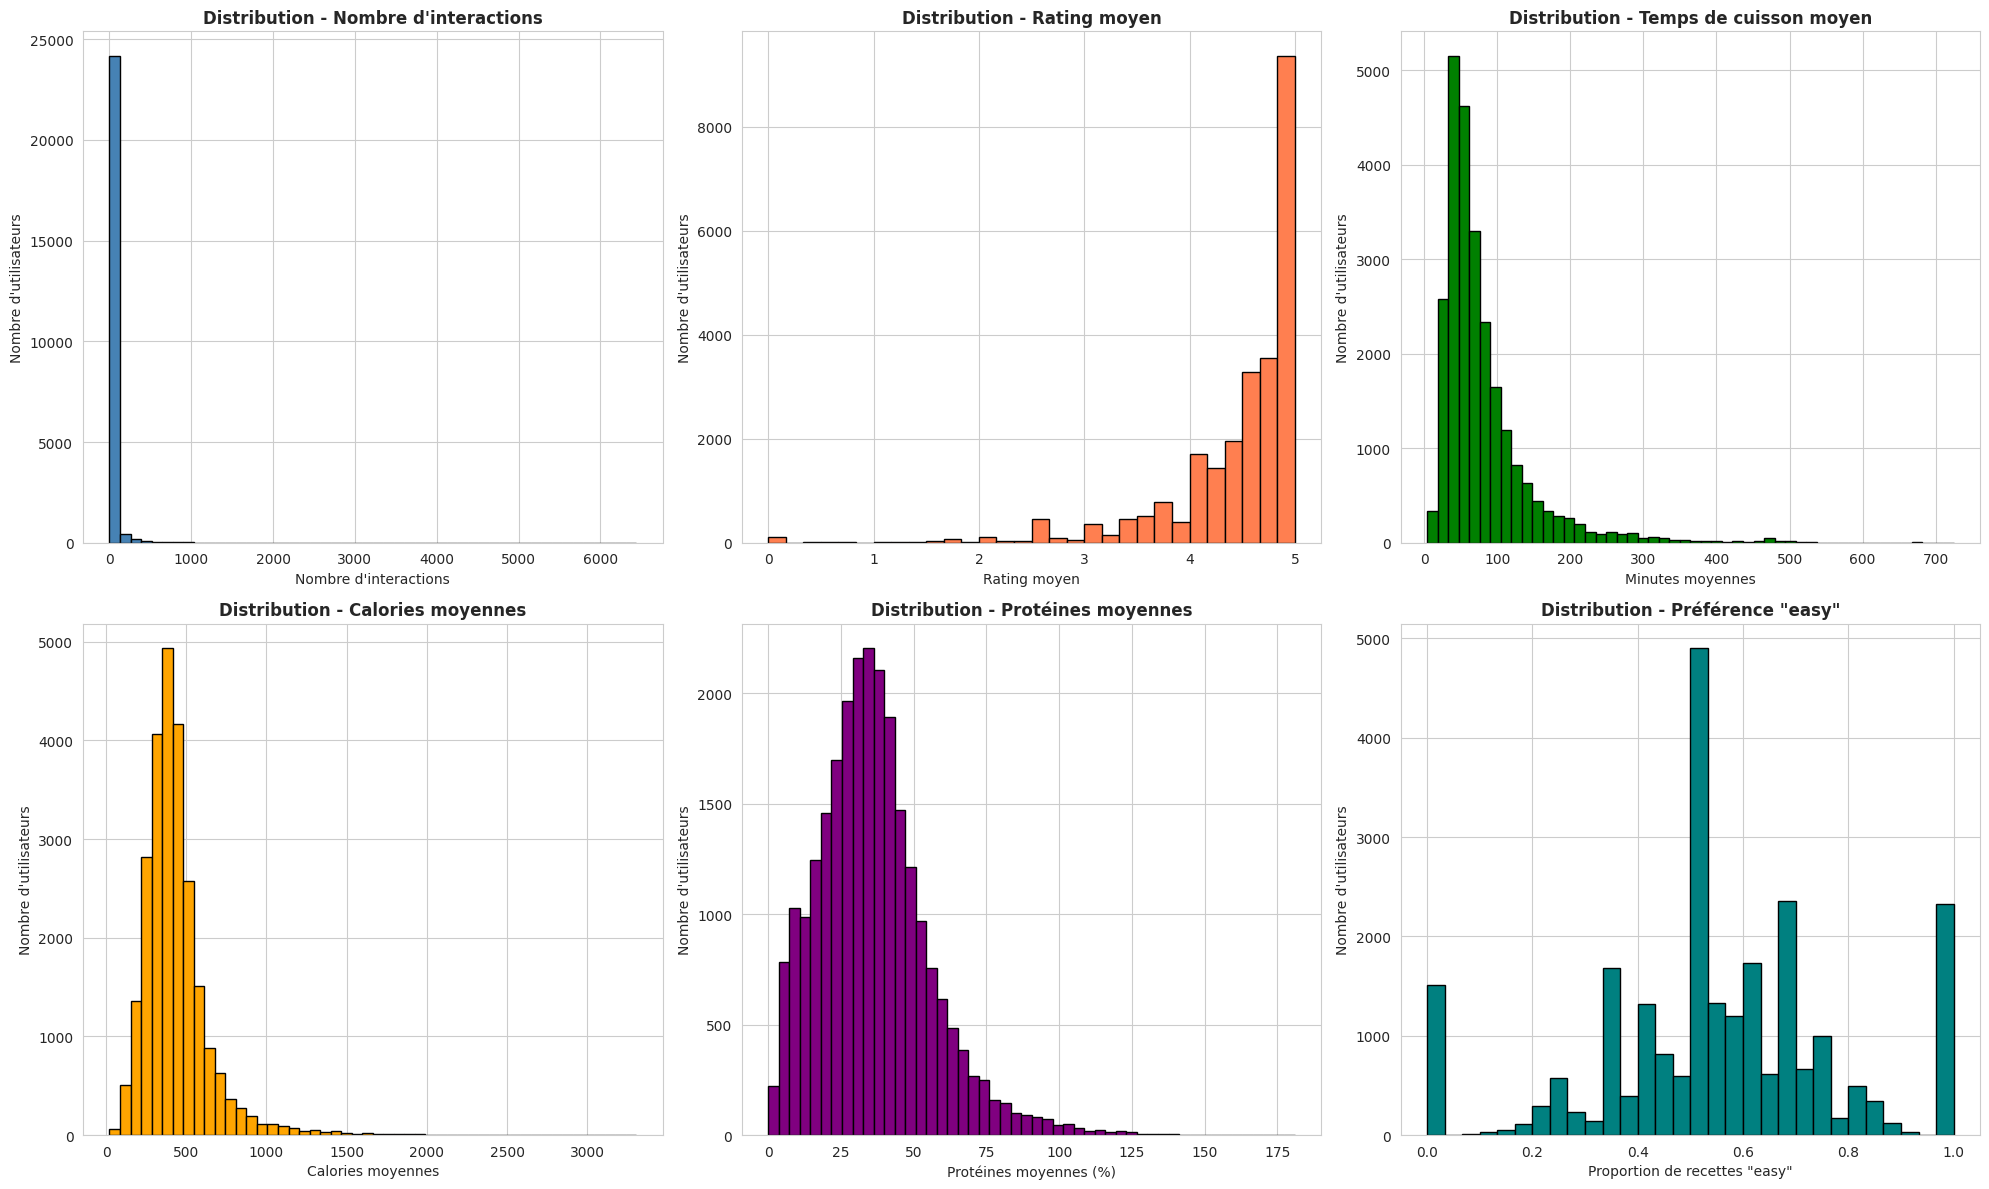


✅ Visualisations terminées


In [15]:
print("=" * 80)
print("VISUALISATIONS DES PROFILS UTILISATEURS")
print("=" * 80)

# Distribution des variables clés
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Interactions
user_profiles_filtered['n_interactions'].hist(bins=50, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Distribution - Nombre d\'interactions', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Nombre d\'interactions')
axes[0, 0].set_ylabel('Nombre d\'utilisateurs')

# Rating moyen
user_profiles_filtered['avg_rating'].hist(bins=30, ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Distribution - Rating moyen', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Rating moyen')
axes[0, 1].set_ylabel('Nombre d\'utilisateurs')

# Temps moyen
user_profiles_filtered['avg_minutes'].hist(bins=50, ax=axes[0, 2], color='green', edgecolor='black')
axes[0, 2].set_title('Distribution - Temps de cuisson moyen', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Minutes moyennes')
axes[0, 2].set_ylabel('Nombre d\'utilisateurs')

# Calories moyennes
user_profiles_filtered['avg_calories'].hist(bins=50, ax=axes[1, 0], color='orange', edgecolor='black')
axes[1, 0].set_title('Distribution - Calories moyennes', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Calories moyennes')
axes[1, 0].set_ylabel('Nombre d\'utilisateurs')

# Protéines moyennes
user_profiles_filtered['avg_protein'].hist(bins=50, ax=axes[1, 1], color='purple', edgecolor='black')
axes[1, 1].set_title('Distribution - Protéines moyennes', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Protéines moyennes (%)')
axes[1, 1].set_ylabel('Nombre d\'utilisateurs')

# Préférence tags "easy"
user_profiles_filtered['pref_tag_easy'].hist(bins=30, ax=axes[1, 2], color='teal', edgecolor='black')
axes[1, 2].set_title('Distribution - Préférence "easy"', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Proportion de recettes "easy"')
axes[1, 2].set_ylabel('Nombre d\'utilisateurs')

plt.tight_layout()
plt.show()

print(f'\n✅ Visualisations terminées')

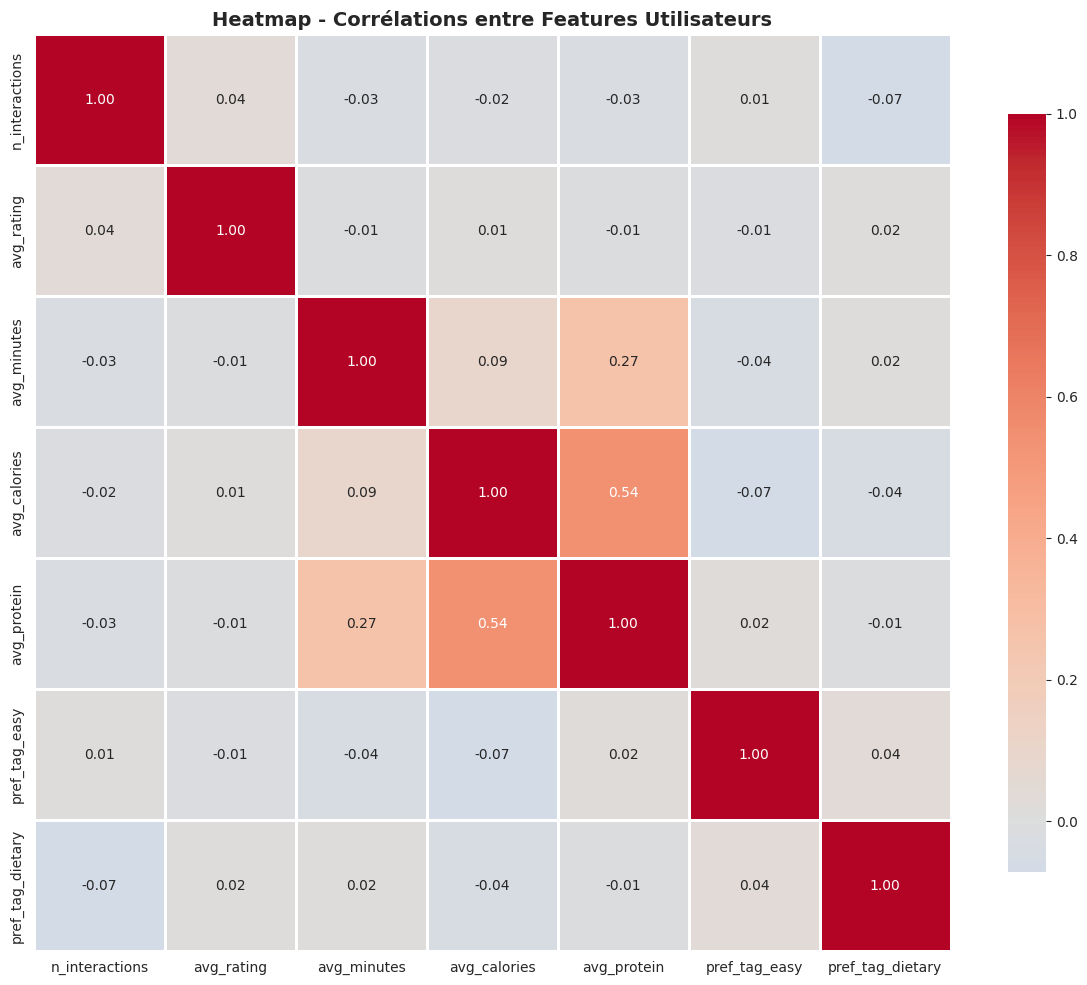

In [16]:
# Heatmap de corrélation (features principales)
feature_cols = ['n_interactions', 'avg_rating', 'avg_minutes', 'avg_calories', 
                'avg_protein', 'pref_tag_easy', 'pref_tag_dietary']
corr_matrix = user_profiles_filtered[feature_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Heatmap - Corrélations entre Features Utilisateurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ÉTAPE 6 - Export Final

In [17]:
print("=" * 80)
print("EXPORT FINAL - USERS_PROFILES.CSV")
print("=" * 80)

# Export du dataset pour clustering
output_file = DATA_PROCESSED / 'users_profiles.csv'
user_profiles_filtered.to_csv(output_file, index=False)

print(f'\n✅ FICHIER EXPORTÉ:')
print(f'   • Chemin: {output_file}')
print(f'   • Shape: {user_profiles_filtered.shape}')
print(f'   • Taille: {output_file.stat().st_size / 1024 / 1024:.2f} MB')

print(f'\n📋 COLONNES EXPORTÉES ({len(user_profiles_filtered.columns)}):')
for i, col in enumerate(user_profiles_filtered.columns, 1):
    print(f'   {i:2d}. {col}')

print(f'\n✅ Dataset prêt pour K-Means Clustering!')

EXPORT FINAL - USERS_PROFILES.CSV

✅ FICHIER EXPORTÉ:
   • Chemin: ../data/processed/users_profiles.csv
   • Shape: (25076, 20)
   • Taille: 4.85 MB

📋 COLONNES EXPORTÉES (20):
    1. user_id
    2. n_interactions
    3. avg_rating
    4. avg_minutes
    5. avg_n_steps
    6. avg_n_ingredients
    7. avg_calories
    8. avg_total_fat
    9. avg_sugar
   10. avg_sodium
   11. avg_protein
   12. avg_saturated_fat
   13. avg_carbohydrates
   14. pref_tag_time_to_make
   15. pref_tag_course
   16. pref_tag_main_ingredient
   17. pref_tag_dietary
   18. pref_tag_easy
   19. pref_tag_occasion
   20. pref_tag_cuisine

✅ Dataset prêt pour K-Means Clustering!


## 📋 Synthèse Finale

In [18]:
print("\n" + "=" * 80)
print("🎉 SYNTHÈSE FINALE - FEATURE ENGINEERING")
print("=" * 80)

print(f'\n OBJECTIF ATTEINT:')
print(f'   Créer des profils utilisateurs agrégés pour clustering K-Means')

print(f'\n DONNÉES SOURCES:')
print(f'   • Recipes clean:      {len(recipes_clean):,}')
print(f'   • Interactions clean: {len(interactions_clean):,}')

print(f'\n🔧 TRAITEMENTS RÉALISÉS:')
print(f'   1. ✅ Jointure interactions ↔ recettes (inner join)')
print(f'   2. ✅ Agrégation par user_id (moyenne pour nutrition/temps, proportion pour tags)')
print(f'   3. ✅ Filtrage utilisateurs (min {min_interactions} interactions)')
print(f'   4. ✅ Vérification qualité (0 valeurs manquantes)')

print(f'\n DATASET FINAL:')
print(f'   • Fichier: users_profiles.csv')
print(f'   • Utilisateurs: {len(user_profiles_filtered):,}')
print(f'   • Features: {len(user_profiles_filtered.columns) - 1}')
print(f'   • Catégories de features:')
print(f'      - Comportement: 2 (n_interactions, avg_rating)')
print(f'      - Temps & Complexité: 3 (avg_minutes, avg_n_steps, avg_n_ingredients)')
print(f'      - Nutrition: 7 (calories, protéines, sucre, sodium, etc.)')
print(f'      - Tags Préférés: 7 (proportions time_to_make, course, dietary, etc.)')

print(f'\n PROCHAINE ÉTAPE:')
print(f'   ✅ Notebook: 04_clustering_kmeans.ipynb')
print(f'      → Normalisation des features (StandardScaler)')
print(f'      → Déterminer K optimal (elbow method, silhouette)')
print(f'      → K-Means clustering (5 segments attendus)')
print(f'      → Analyse et interprétation des clusters')
print("=" * 80)


🎉 SYNTHÈSE FINALE - FEATURE ENGINEERING

 OBJECTIF ATTEINT:
   Créer des profils utilisateurs agrégés pour clustering K-Means

 DONNÉES SOURCES:
   • Recipes clean:      231,635
   • Interactions clean: 698,901

🔧 TRAITEMENTS RÉALISÉS:
   1. ✅ Jointure interactions ↔ recettes (inner join)
   2. ✅ Agrégation par user_id (moyenne pour nutrition/temps, proportion pour tags)
   3. ✅ Filtrage utilisateurs (min 2 interactions)
   4. ✅ Vérification qualité (0 valeurs manquantes)

 DATASET FINAL:
   • Fichier: users_profiles.csv
   • Utilisateurs: 25,076
   • Features: 19
   • Catégories de features:
      - Comportement: 2 (n_interactions, avg_rating)
      - Temps & Complexité: 3 (avg_minutes, avg_n_steps, avg_n_ingredients)
      - Nutrition: 7 (calories, protéines, sucre, sodium, etc.)
      - Tags Préférés: 7 (proportions time_to_make, course, dietary, etc.)

 PROCHAINE ÉTAPE:
   ✅ Notebook: 04_clustering_kmeans.ipynb
      → Normalisation des features (StandardScaler)
      → Déterminer